In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_squared_error, mean_absolute_error,  mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

In [2]:
folder = r'C:\Users\User\Documents\Bismillah'
tahun_data = [2020, 2021, 2022, 2023, 2024]
list_df = []

for tahun in tahun_data:
    path = os.path.join(folder, f'{tahun} Summary.xlsx')
    df = pd.read_excel(path)
    df['Tahun'] = tahun
    list_df.append(df)

df_all = pd.concat(list_df, ignore_index=True)

# EDA

In [3]:
print("--- Dataset Info ---")
print(df_all.info(), '\n')

print("--- Missing Values per Column ---")
print(df_all.isnull().sum(), '\n')

print("--- Duplicate Rows ---")
print(df_all.duplicated().sum(), '\n')


if df_all.duplicated().any():
    df_all = df_all.drop_duplicates()
    print("Duplicates dropped, new shape:", df_all.shape)


numeric_cols = df_all.select_dtypes(include=['float64', 'int64'])
print("--- Correlation Matrix ---")
print(numeric_cols.corr(), '\n')

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Vendor        318 non-null    object 
 1   Brand         313 non-null    object 
 2   JanQty        310 non-null    float64
 3   JanNet Sales  310 non-null    float64
 4   FebQty        310 non-null    float64
 5   FebNet Sales  310 non-null    object 
 6   MarQty        312 non-null    float64
 7   MarNet Sales  312 non-null    object 
 8   AprQty        308 non-null    float64
 9   AprNet Sales  308 non-null    object 
 10  JunQty        311 non-null    float64
 11  JunNet Sales  311 non-null    object 
 12  JulQty        310 non-null    float64
 13  JulNet Sales  310 non-null    object 
 14  AgtQty        308 non-null    float64
 15  AgtNet Sales  307 non-null    object 
 16  SepQty        308 non-null    float64
 17  SepNet Sales  307 non-null    object 
 18  OktQty   

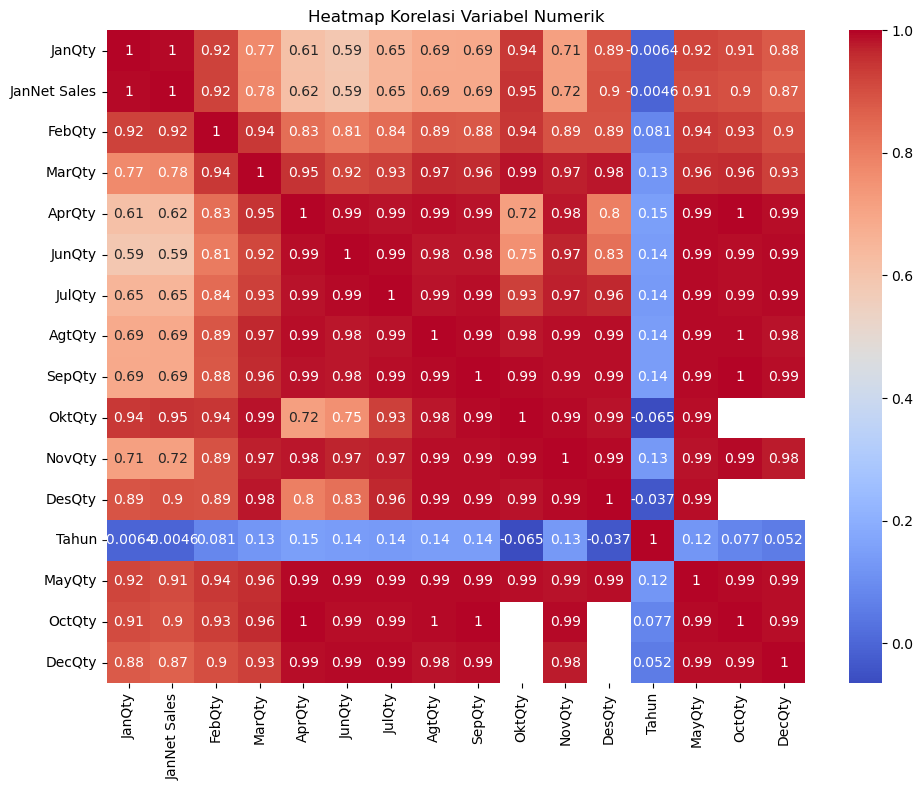

In [4]:
plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Variabel Numerik")
plt.tight_layout()
plt.show()

# Konversi Data Penjualan Ke Format Time Series (Long Format)

In [5]:
bulan_nama = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Agt','Sep','Okt','Nov','Des']
records = []
for _, row in df_all.iterrows():
    for i, b in enumerate(bulan_nama, start=1):
        # Cek variasi nama kolom dengan atau tanpa spasi
        col1 = f'{b}Net Sales'
        col2 = f'{b} Net Sales'
        if col1 in df_all.columns:
            col = col1
        elif col2 in df_all.columns:
            col = col2
        else:
            col = None
        
        if col is not None:
            val = row.get(col, np.nan)
            if pd.notna(val):
                try:
                    clean_val = float(str(val).replace(',','').strip())
                    records.append({'Tahun': row['Tahun'], 'Bulan': i, 'Penjualan_Bersih': clean_val})
                except:
                    pass

df_ts = pd.DataFrame(records)
df_ts['Tanggal'] = pd.to_datetime(df_ts['Tahun'].astype(str) + '-' + df_ts['Bulan'].astype(str) + '-01')

df_monthly = df_ts.groupby('Tanggal')['Penjualan_Bersih'].sum().reset_index()

print("Missing in time series:", df_monthly.isnull().sum(), '\n')
print("Duplicates in TS:", df_monthly.duplicated().sum(), '\n')
print(df_monthly[['Tanggal', 'Penjualan_Bersih']].head(10))  # tampilkan 10 baris pertama


df_monthly['Bulan'] = df_monthly['Tanggal'].dt.month
df_monthly['Lag_1'] = df_monthly['Penjualan_Bersih'].shift(1)
df_monthly = df_monthly.dropna().reset_index(drop=True)

Missing in time series: Tanggal             0
Penjualan_Bersih    0
dtype: int64 

Duplicates in TS: 0 

     Tanggal  Penjualan_Bersih
0 2020-01-01      2.485500e+10
1 2020-02-01      1.048432e+10
2 2020-03-01      5.920911e+09
3 2020-04-01      1.650581e+09
4 2020-06-01      1.547015e+09
5 2020-07-01      2.851217e+09
6 2020-08-01      3.987961e+09
7 2020-09-01      4.440590e+09
8 2020-10-01      4.572613e+09
9 2020-11-01      5.247716e+09


In [6]:

df_monthly_sorted = df_monthly.sort_values('Tanggal').reset_index(drop=True)

train_size_70 = int(len(df_monthly_sorted) * 0.7)
train_70 = df_monthly_sorted.iloc[:train_size_70]
test_30 = df_monthly_sorted.iloc[train_size_70:]

print("Pembagian 70:30 berdasarkan urutan waktu:")
print("Jumlah data train:", len(train_70))
print("Jumlah data test :", len(test_30))

Pembagian 70:30 berdasarkan urutan waktu:
Jumlah data train: 36
Jumlah data test : 16


# Preprocessing

In [18]:
# Cek missing dan duplikasi
print("Missing in time series:", df_monthly.isnull().sum(), '\n')
print("Duplicates in TS:", df_monthly.duplicated().sum(), '\n')

# Buat fitur tambahan (jika belum)
df_monthly['Bulan'] = df_monthly['Tanggal'].dt.month
df_monthly['Lag_1'] = df_monthly['Penjualan_Bersih'].shift(1)
df_monthly = df_monthly.dropna().reset_index(drop=True)

# Tentukan fitur yang akan digunakan
features = ['Penjualan_Bersih', 'Bulan', 'Lag_1']

# Urutkan berdasarkan tanggal
df_monthly_sorted = df_monthly.sort_values('Tanggal').reset_index(drop=True)

# Bagi data 70:30
split_index_70 = int(len(df_monthly_sorted) * 0.7)
train_70_df = df_monthly_sorted.iloc[:split_index_70]
val_30_df   = df_monthly_sorted.iloc[split_index_70:]

# Scaling
scaler_70 = MinMaxScaler()
scaler_70.fit(train_70_df[features])

train_70_scaled = scaler_70.transform(train_70_df[features])
val_30_scaled   = scaler_70.transform(val_30_df[features])

print("Preprocessing 70:30 selesai:")
print("Train shape:", train_70_scaled.shape)
print("Val shape  :", val_30_scaled.shape)


Missing in time series: Tanggal             0
Penjualan_Bersih    0
Bulan               0
Lag_1               0
dtype: int64 

Duplicates in TS: 0 

Preprocessing 70:30 selesai:
Train shape: (35, 3)
Val shape  : (15, 3)


In [19]:
# --- Fungsi untuk membuat dataset dalam bentuk time steps ---
def create_dataset(dataset, time_steps=12):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:i + time_steps, :])   # semua fitur
        y.append(dataset[i + time_steps, 0])     # kolom ke-0 adalah target
    return np.array(X), np.array(y)
# Parameter time steps
time_steps = 12

In [20]:
# Buat dataset time steps
X_train_70, y_train_70 = create_dataset(train_70_scaled, time_steps)
X_test_30, y_test_30 = create_dataset(val_30_scaled, time_steps)

print("X_train_70 shape:", X_train_70.shape)
print("X_test_30 shape :", X_test_30.shape)

# Reshape jika hanya 2 dimensi (untuk LSTM butuh 3D input)
if len(X_train_70.shape) == 2:
    X_train_70 = X_train_70.reshape((X_train_70.shape[0], X_train_70.shape[1], 1))
if len(X_test_30.shape) == 2:
    X_test_30 = X_test_30.reshape((X_test_30.shape[0], X_test_30.shape[1], 1))

# --- Fungsi membuat sequence sliding window (opsional) ---
def create_sequences(data, window=6):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window, 1:])  # semua fitur kecuali target (kolom ke-1 dst)
        y.append(data[i + window, 0])   # target tetap Penjualan_Bersih (kolom ke-0)
    return np.array(X), np.array(y)

# Buat sequence untuk train dan val (berdasarkan 70:30)
X_train_seq_70, y_train_seq_70 = create_sequences(train_70_scaled, window=6)

# Untuk validasi: ambil 6 data terakhir dari train + test_30
X_val_seq_30, y_val_seq_30 = create_sequences(np.vstack([train_70_scaled[-6:], val_30_scaled]), window=6)

print("X_train_seq_70 shape:", X_train_seq_70.shape)
print("y_train_seq_70 shape:", y_train_seq_70.shape)
print("X_val_seq_30 shape :", X_val_seq_30.shape)
print("y_val_seq_30 shape :", y_val_seq_30.shape)

# Input shape untuk LSTM
input_shape_70 = (X_train_seq_70.shape[1], X_train_seq_70.shape[2])
print("Input shape untuk LSTM (70:30):", input_shape_70)


X_train_70 shape: (23, 12, 2)
X_test_30 shape : (3, 12, 2)
X_train_seq_70 shape: (29, 6, 2)
y_train_seq_70 shape: (29,)
X_val_seq_30 shape : (15, 6, 2)
y_val_seq_30 shape : (15,)
Input shape untuk LSTM (70:30): (6, 2)


# LSTM

In [21]:
# Bangun model stacked LSTM untuk data 70:30
model_70 = Sequential([
    Input(shape=(X_train_seq_70.shape[1], X_train_seq_70.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

# Kompilasi model
model_70.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Ringkasan model
model_70.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 6, 64)               │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,601 (115.63 KB)

 Trainable params: 29,601 (115.63 KB)

 Non-trainable params: 0 (0.00 B)

# Training

In [22]:
# Gunakan early stopping untuk mencegah overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training model dengan data 70:30
history = model_70.fit(
    X_train_seq_70, y_train_seq_70,
    epochs=100,
    batch_size=16,
    validation_data=(X_val_seq_30, y_val_seq_30),
    callbacks=[early_stop],
    verbose=1
)

# Catat performa akhir
val_loss = history.history['val_loss'][-1]
print(f"Final Validation Loss (MSE - 70:30): {val_loss:.4f}")

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - loss: 0.1599 - mae: 0.2727 - val_loss: 0.6572 - val_mae: 0.8070
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.1027 - mae: 0.1982 - val_loss: 0.5570 - val_mae: 0.7422
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0926 - mae: 0.1916 - val_loss: 0.4614 - val_mae: 0.6745
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0909 - mae: 0.1978 - val_loss: 0.3750 - val_mae: 0.6066
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0506 - mae: 0.1628 - val_loss: 0.3078 - val_mae: 0.5479
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0476 - mae: 0.1523 - val_loss: 0.2525 - val_mae: 0.4941
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0829 - mae: 0.2146 - val_loss: 0.2081 - val_mae: 0.4462
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0667 - mae: 0.2061 - val_loss: 0.1846 - val_mae: 0.4186
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0586 - mae:

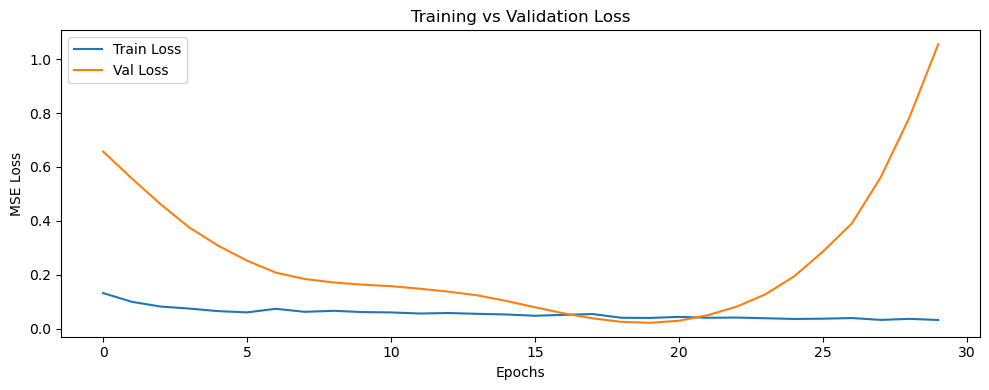

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
# Prediksi pada data validasi
y_pred_70 = model_70.predict(X_val_seq_30)

# Dummy array untuk inverse transform
dummy_val = np.zeros((len(y_val_seq_30), val_30_scaled.shape[1]))
dummy_pred = np.zeros((len(y_pred_70), val_30_scaled.shape[1]))

dummy_val[:, 0] = y_val_seq_30
dummy_pred[:, 0] = y_pred_70.flatten()

# Kembalikan ke skala asli
y_val_actual_70 = scaler_70.inverse_transform(dummy_val)[:, 0]
y_val_pred_70 = scaler_70.inverse_transform(dummy_pred)[:, 0]
print("y_val (real):", y_val_actual_70[:5])
print("y_pred (real):", y_val_pred_70[:5])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
y_val (real): [1.74641937e+10 1.71205149e+10 1.93402845e+10 1.88768780e+10
 2.00815683e+10]
y_pred (real): [1.14764924e+10 1.33143855e+10 1.55429604e+10 1.71699266e+10
 1.85740345e+10]


In [25]:
# Hitung MSE, MAE, MAPE
mse_70 = mean_squared_error(y_val_actual_70, y_val_pred_70)
mae_70 = mean_absolute_error(y_val_actual_70, y_val_pred_70)
mape_70 = np.mean(np.abs((y_val_actual_70 - y_val_pred_70) / y_val_actual_70)) * 100

print("=== Evaluasi Model LSTM 70:30 ===")
print(f"MSE  : {mse_70:.2f}")
print(f"MAE  : {mae_70:.2f}")
print(f"MAPE : {mape_70:.2f}%")

=== Evaluasi Model LSTM 70:30 ===
MSE  : 7322664602429872128.00
MAE  : 2102524142.80
MAPE : 12.37%


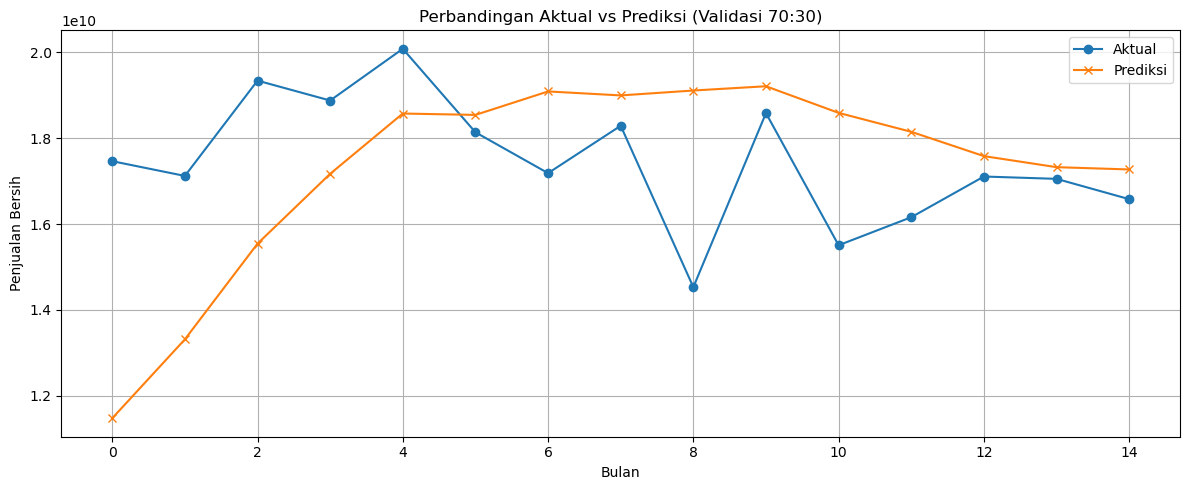

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(y_val_actual_70, label='Aktual', marker='o')
plt.plot(y_val_pred_70, label='Prediksi', marker='x')
plt.title('Perbandingan Aktual vs Prediksi (Validasi 70:30)')
plt.xlabel('Bulan')
plt.ylabel('Penjualan Bersih')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [30]:
# === Fungsi untuk membuat dataset sekuensial ===
def create_dataset(dataset, time_steps=6):
    X, y = [], []
    for i in range(len(dataset)-time_steps):
        X.append(dataset[i:i+time_steps, 1:])  # Ambil fitur Bulan & Lag_1
        y.append(dataset[i+time_steps, 0])     # Target: Penjualan_Bersih
    return np.array(X), np.array(y)

# === Siapkan data validasi ===
X_val_seq_70, y_val_seq_70 = create_dataset(np.vstack([train_70_scaled[-6:], val_30_scaled]), time_steps=6)

# === Fungsi untuk mengembalikan skala asli dari prediksi ===
def inv_transform_70(y_preds, X_prev):
    if X_prev.ndim == 3:
        last_feats = X_prev[:, -1, :]
    else:
        last_feats = X_prev
    arr = np.hstack([y_preds.reshape(-1, 1), last_feats])
    return scaler_70.inverse_transform(arr)[:, 0]

# === Siapkan fitur validasi untuk inverse transform ===
X_val_full_70 = np.vstack([train_70_scaled[-6:], val_30_scaled])
X_val_window_feats_70 = np.array([
    X_val_full_70[i + 6 - 1, 1:]
    for i in range(len(val_30_scaled))
])

# === Prediksi validasi ===
desired_steps = 3
batch_size_pred = max(1, len(X_val_seq_70) // desired_steps)
preds_val_70 = model_70.predict(X_val_seq_70, batch_size=batch_size_pred, verbose=1)

# Inverse transform hasil prediksi dan aktual
y_val_actual_70 = inv_transform_70(y_val_seq_70, X_val_window_feats_70)
y_val_pred_70   = inv_transform_70(preds_val_70.flatten(), X_val_window_feats_70)

# Tampilkan hasil
print("=== Hasil Prediksi Validasi 70:30 ===")
for i in range(len(y_val_actual_70)):
    print(f"Bulan ke-{i+1}: Aktual = {y_val_actual_70[i]:.2f}, Prediksi = {y_val_pred_70[i]:.2f}")

# === Prediksi 12 Bulan ke Depan Berdasarkan 70:30 ===
future_preds_70 = []
data_full_70 = np.vstack([train_70_scaled, val_30_scaled])
last_window_70 = data_full_70[-6:, 1:]

for i in range(12):
    X_input = last_window_70.reshape(1, 6, 2)
    y_pred_scaled = model_70.predict(X_input)

    # Inverse transform
    y_pred_actual = scaler_70.inverse_transform(
        np.hstack([y_pred_scaled.flatten().reshape(-1, 1), last_window_70[-1].reshape(1, -1)])
    )[:, 0][0]

    # Hindari prediksi negatif
    y_pred_actual = max(0, y_pred_actual)

    future_preds_70.append(y_pred_actual)

    # Perbarui window
    next_month = ((last_window_70[-1, 0] % 12) + 1)
    next_input = np.array([[next_month, y_pred_scaled[0][0]]])
    last_window_70 = np.vstack([last_window_70[1:], next_input])

# Tampilkan prediksi 12 bulan
print("\n=== Prediksi 12 Bulan ke Depan (70:30) ===")
for i, val in enumerate(future_preds_70, 1):
    print(f"Bulan ke-{i}: Prediksi = {val:.2f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 
=== Hasil Prediksi Validasi 70:30 ===
Bulan ke-1: Aktual = 17464193698.92, Prediksi = 11476492402.07
Bulan ke-2: Aktual = 17120514882.00, Prediksi = 13314385478.02
Bulan ke-3: Aktual = 19340284500.00, Prediksi = 15542960372.78
Bulan ke-4: Aktual = 18876877977.14, Prediksi = 17169926589.54
Bulan ke-5: Aktual = 20081568328.66, Prediksi = 18574034450.97
Bulan ke-6: Aktual = 18137389202.88, Prediksi = 18542018341.79
Bulan ke-7: Aktual = 17185132762.68, Prediksi = 19088500130.74
Bulan ke-8: Aktual = 18289071590.86, Prediksi = 18995900074.85
Bulan ke-9: Aktual = 14530070820.88, Prediksi = 19110040464.23
Bulan ke-10: Aktual = 18583582492.66, Prediksi = 19209217779.01
Bulan ke-11: Aktual = 15506281002.34, Prediksi = 18589284340.37
Bulan ke-12: Aktual = 16158664602.50, Prediksi = 18148037611.48
Bulan ke-13: Aktual = 17106937752.20, Prediksi = 17582356547.29
Bulan ke-14: Aktual = 17052407543.68, Prediksi = 17324755718.59
Bulan ke-15: Aktual = 16579677096.42

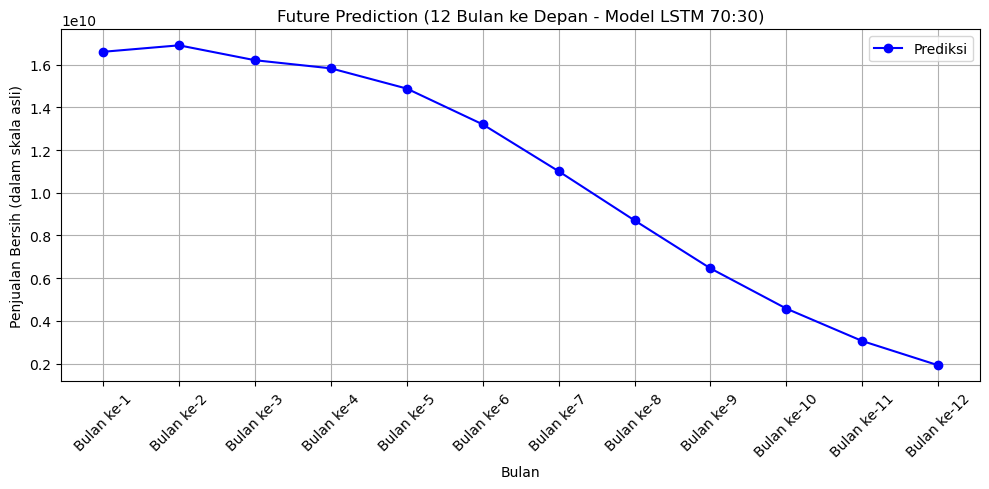

In [31]:

# Hasil prediksi 12 bulan (model 70:30)
future_preds_70 = [
    16596273621.07, 16898430903.82, 16201585023.31, 15821792881.38,
    14874148955.93, 13199027610.80, 11005830218.17, 8705323018.89,
    6459980303.94, 4578194716.41, 3061147701.10, 1925744195.82
]

# Label bulan ke-1 hingga ke-12
bulan_labels_70 = [f"Bulan ke-{i}" for i in range(1, 13)]

# Visualisasikan grafik prediksi 12 bulan ke depan
plt.figure(figsize=(10, 5))
plt.plot(future_preds_70, marker='o', linestyle='-', color='blue', label='Prediksi')
plt.xticks(ticks=range(12), labels=bulan_labels_70, rotation=45)
plt.title("Future Prediction (12 Bulan ke Depan - Model LSTM 70:30)")
plt.xlabel("Bulan")
plt.ylabel("Penjualan Bersih (dalam skala asli)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()